<a href="https://colab.research.google.com/github/rizkystp1003/ANALISIS-SENTIMEN-MEDIA-SOSIAL-TWITTER-TERHADAP-TIMNAS-MENGGUNAKAN-METODE-NAIVE-BAYES-CLASSIFIER/blob/main/Analisis_Sentimen_Media_Sosial_Twitter_terhadap_Timnas_Menggunakan_Metode_Naive_Bayes_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TEXT PROCESSING**

In [ ]:
!pip install Sastrawi

In [ ]:
import pandas as pd
import re
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from collections import Counter
import random
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
import pandas as pd

timnas_df = pd.read_csv("/content/drive/MyDrive/Datasets/timnas.csv")
timnas_df.head()

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1905125629919375595,Thu Mar 27 23:58:02 +0000 2025,0,@detikcom Supaya timnas Indonesia labih baik l...,1905409007923397044,NaN,detikcom,in,NaN,0,0,0,https://x.com/antopst77/status/190540900792339...,1807587566826512385,antopst77
1,1905405726186766633,Thu Mar 27 23:45:00 +0000 2025,2,Cerita Marselino Ferdinan soal Usaha Bangun Ch...,1905405726186766633,NaN,NaN,in,Jakarta,0,0,0,https://x.com/okezonenews/status/1905405726186...,47274731,okezonenews
2,1904444794170188121,Thu Mar 27 23:41:29 +0000 2025,0,@erickthohir Indonesia jiwa petarung &amp; jiw...,1905404841238954249,NaN,erickthohir,in,NaN,0,0,0,https://x.com/Game26muda/status/19054048412389...,1681592056614117377,Game26muda
3,1903807175572783465,Thu Mar 27 23:41:01 +0000 2025,0,@erickthohir Indonesia jiwa petarung &amp; jiw...,1905404725786489178,NaN,erickthohir,in,NaN,0,0,0,https://x.com/Game26muda/status/19054047257864...,1681592056614117377,Game26muda
4,1905402470307954986,Thu Mar 27 23:32:04 +0000 2025,0,RESMI: pelatih timnas Iraq dipecat Setelah me...,1905402470307954986,https://pbs.twimg.com/media/GnFZbvcbkAA4VVp.jpg,NaN,in,NaN,0,0,0,https://x.com/MAS_FAISAL911/status/19054024703...,1889983538008903680,MAS_FAISAL911


In [ ]:
# hanya mengambil kolom full_text
timnas_df = timnas_df[['full_text']]
timnas_df.head()

,full_text
0,@detikcom Supaya timnas Indonesia labih baik l...
1,Cerita Marselino Ferdinan soal Usaha Bangun Ch...
2,@erickthohir Indonesia jiwa petarung &amp; jiw...
3,@erickthohir Indonesia jiwa petarung &amp; jiw...
4,RESMI: pelatih timnas Iraq dipecat Setelah me...


In [ ]:
# CASE FOLDING
def case_folding(text):
    return text.lower()

# Mengaplikasikan case folding pada kolom 'full_text'
timnas_df['case_folding'] = timnas_df['full_text'].apply(case_folding)

# Menampilkan hasil case folding
timnas_df[['full_text', 'case_folding']].head()


,full_text,case_folding
0,@detikcom Supaya timnas Indonesia labih baik l...,@detikcom supaya timnas indonesia labih baik l...
1,Cerita Marselino Ferdinan soal Usaha Bangun Ch...,cerita marselino ferdinan soal usaha bangun ch...
2,@erickthohir Indonesia jiwa petarung &amp; jiw...,@erickthohir indonesia jiwa petarung &amp; jiw...
3,@erickthohir Indonesia jiwa petarung &amp; jiw...,@erickthohir indonesia jiwa petarung &amp; jiw...
4,RESMI: pelatih timnas Iraq dipecat Setelah me...,resmi: pelatih timnas iraq dipecat setelah me...


In [ ]:
# CLEANING
def clean_text(text):
    # Menghapus URL
    text = re.sub(r'http\S+|www\S+', '', text)
    # Menghapus karakter non-alfabet (hanya menyisakan huruf dan spasi)
    text = re.sub(r'[^a-z\s]', '', text)
    # Menghapus spasi ekstra
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Mengaplikasikan cleaning pada kolom 'cleaned_text'
timnas_df['cleaned_text'] = timnas_df['case_folding'].apply(clean_text)

# Menampilkan hasil setelah cleaning
timnas_df[['full_text', 'cleaned_text']].head()


,full_text,cleaned_text
0,@detikcom Supaya timnas Indonesia labih baik l...,detikcom supaya timnas indonesia labih baik lagi
1,Cerita Marselino Ferdinan soal Usaha Bangun Ch...,cerita marselino ferdinan soal usaha bangun ch...
2,@erickthohir Indonesia jiwa petarung &amp; jiw...,erickthohir indonesia jiwa petarung amp jiwa p...
3,@erickthohir Indonesia jiwa petarung &amp; jiw...,erickthohir indonesia jiwa petarung amp jiwa p...
4,RESMI: pelatih timnas Iraq dipecat Setelah me...,resmi pelatih timnas iraq dipecat setelah mene...


In [ ]:
# TOKENIZING
def tokenize_text(text):
    return word_tokenize(text)

# Mengaplikasikan tokenisasi pada kolom 'cleaned_text'
timnas_df['tokens'] = timnas_df['cleaned_text'].apply(tokenize_text)

# Menampilkan hasil tokenisasi
timnas_df[['cleaned_text', 'tokens']].head()

,cleaned_text,tokens
0,detikcom supaya timnas indonesia labih baik lagi,"[detikcom, supaya, timnas, indonesia, labih, b..."
1,cerita marselino ferdinan soal usaha bangun ch...,"[cerita, marselino, ferdinan, soal, usaha, ban..."
2,erickthohir indonesia jiwa petarung amp jiwa p...,"[erickthohir, indonesia, jiwa, petarung, amp, ..."
3,erickthohir indonesia jiwa petarung amp jiwa p...,"[erickthohir, indonesia, jiwa, petarung, amp, ..."
4,resmi pelatih timnas iraq dipecat setelah mene...,"[resmi, pelatih, timnas, iraq, dipecat, setela..."


In [ ]:
# STOPWORD REMOVAL
# Menggunakan kamus stopword.txt
stopword_file_path = '/content/drive/MyDrive/Datasets/stopword.txt'

# Membaca stopwords dari file
with open(stopword_file_path, 'r') as f:
    custom_stopwords = set(f.read().splitlines())

# Daftar stopwords manual
manual_stopwords = set([
    'amp',
])

# Menggabungkan stopwords dari file dan manual
custom_stopwords = custom_stopwords.union(manual_stopwords)

# Menampilkan jumlah stopwords yang telah digabungkan
print(len(custom_stopwords), "stopwords setelah digabungkan (file + manual)")

# Fungsi untuk menghapus stopwords dari tokens
def remove_stopwords(tokens):
    return [word for word in tokens if word not in custom_stopwords]

# Mengaplikasikan penghapusan stopwords pada kolom 'tokens' di dataset timnas_df
timnas_df['stopword'] = timnas_df['tokens'].apply(remove_stopwords)

# Menampilkan hasil setelah penghapusan stopwords
timnas_df[['full_text', 'tokens', 'stopword']].head()


769 stopwords setelah digabungkan (file + manual)


,full_text,tokens,stopword
0,@detikcom Supaya timnas Indonesia labih baik l...,"[detikcom, supaya, timnas, indonesia, labih, b...","[detikcom, timnas, indonesia, labih]"
1,Cerita Marselino Ferdinan soal Usaha Bangun Ch...,"[cerita, marselino, ferdinan, soal, usaha, ban...","[cerita, marselino, ferdinan, usaha, bangun, c..."
2,@erickthohir Indonesia jiwa petarung &amp; jiw...,"[erickthohir, indonesia, jiwa, petarung, amp, ...","[erickthohir, indonesia, jiwa, petarung, jiwa,..."
3,@erickthohir Indonesia jiwa petarung &amp; jiw...,"[erickthohir, indonesia, jiwa, petarung, amp, ...","[erickthohir, indonesia, jiwa, petarung, jiwa,..."
4,RESMI: pelatih timnas Iraq dipecat Setelah me...,"[resmi, pelatih, timnas, iraq, dipecat, setela...","[resmi, pelatih, timnas, iraq, dipecat, menema..."


In [ ]:
# NORMALISASI

# menggunakan kamus normalisasi kamuskatabaku.xlsx
kamus_file_path = '/content/drive/MyDrive/Datasets/kamuskatabaku.xlsx'

# Baca kamus dari file Excel
kamus_df = pd.read_excel(kamus_file_path)

# Menampilkan beberapa baris pertama untuk memeriksa struktur data
kamus_df.head()

# Pastikan kolom yang digunakan adalah kolom 'kata_tidak_baku' dan 'kata_baku'
# Gantilah jika kolom pada kamus Anda berbeda nama
kamus_dict = dict(zip(kamus_df['tidak_baku'], kamus_df['kata_baku']))

# Fungsi untuk normalisasi (mengganti kata tidak baku dengan kata baku)
def normalize_text(tokens):
    return [kamus_dict.get(word, word) for word in tokens]

# Terapkan normalisasi pada kolom 'filtered_tokens'
timnas_df['normalized'] = timnas_df['stopword'].apply(normalize_text)

# Menampilkan hasil normalisasi
timnas_df[['full_text', 'stopword', 'normalized']].head()


,full_text,stopword,normalized
0,@detikcom Supaya timnas Indonesia labih baik l...,"[detikcom, timnas, indonesia, labih]","[detikcom, timnas, indonesia, labih]"
1,Cerita Marselino Ferdinan soal Usaha Bangun Ch...,"[cerita, marselino, ferdinan, usaha, bangun, c...","[cerita, marselino, ferdinan, usaha, bangun, c..."
2,@erickthohir Indonesia jiwa petarung &amp; jiw...,"[erickthohir, indonesia, jiwa, petarung, jiwa,...","[erickthohir, indonesia, jiwa, petarung, jiwa,..."
3,@erickthohir Indonesia jiwa petarung &amp; jiw...,"[erickthohir, indonesia, jiwa, petarung, jiwa,...","[erickthohir, indonesia, jiwa, petarung, jiwa,..."
4,RESMI: pelatih timnas Iraq dipecat Setelah me...,"[resmi, pelatih, timnas, iraq, dipecat, menema...","[resmi, pelatih, timnas, iraq, dipecat, menema..."


In [ ]:
# Inisialisasi objek stemmer dari Sastrawi
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Fungsi untuk melakukan stemming pada tokens
def stem_tokens(tokens):
    return [stemmer.stem(word) for word in tokens]

# Terapkan stemming pada kolom 'normalized'
timnas_df['stemming'] = timnas_df['normalized'].apply(stem_tokens)

# Menampilkan hasil setelah stemming
timnas_df[['full_text', 'normalized', 'stemming']].head()

,full_text,normalized,stemming
0,@detikcom Supaya timnas Indonesia labih baik l...,"[detikcom, timnas, indonesia, labih]","[detikcom, timnas, indonesia, labih]"
1,Cerita Marselino Ferdinan soal Usaha Bangun Ch...,"[cerita, marselino, ferdinan, usaha, bangun, c...","[cerita, marselino, ferdinan, usaha, bangun, c..."
2,@erickthohir Indonesia jiwa petarung &amp; jiw...,"[erickthohir, indonesia, jiwa, petarung, jiwa,...","[erickthohir, indonesia, jiwa, tarung, jiwa, t..."
3,@erickthohir Indonesia jiwa petarung &amp; jiw...,"[erickthohir, indonesia, jiwa, petarung, jiwa,...","[erickthohir, indonesia, jiwa, tarung, jiwa, t..."
4,RESMI: pelatih timnas Iraq dipecat Setelah me...,"[resmi, pelatih, timnas, iraq, dipecat, menema...","[resmi, latih, timnas, iraq, pecat, tani, timn..."


In [ ]:
# menyimpan hasil text processing ke google drive
output_csv_path = '/content/drive/MyDrive/Datasets/timnas_processed.csv'
timnas_df.to_csv(output_csv_path, index=False)
print(f"Hasil text processing disimpan di {output_csv_path}")

Hasil text processing disimpan di /content/drive/MyDrive/Datasets/timnas_processed.csv


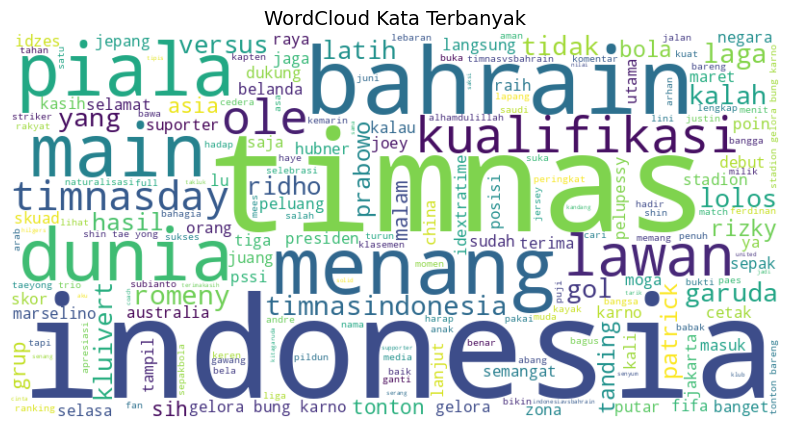

In [ ]:
# WORDCLOUD
tokens = timnas_df['stemming'].explode().tolist()

# Hitung frekuensi kata
word_freq = Counter(tokens)

wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud Kata Terbanyak", fontsize=14)
plt.show()


<ipython-input-25-e3e33f67c32e>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(words), y=list(counts), palette="viridis")


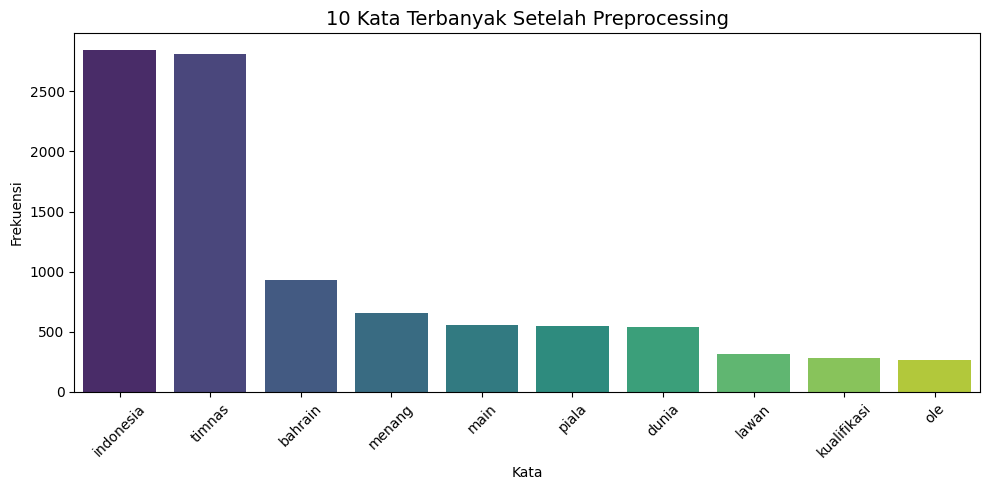

In [ ]:
# BAR CHART FREKUENSI KATA
# Ambil N kata paling sering (misal 10)
most_common_words = word_freq.most_common(10)
words, counts = zip(*most_common_words)

plt.figure(figsize=(10, 5))
sns.barplot(x=list(words), y=list(counts), palette="viridis")
plt.title("10 Kata Terbanyak Setelah Preprocessing", fontsize=14)
plt.xlabel("Kata")
plt.ylabel("Frekuensi")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **LABELING**

In [ ]:
positive_file_path = '/content/drive/MyDrive/Datasets/positive.tsv'
negative_file_path = '/content/drive/MyDrive/Datasets/negative.tsv'

# Assuming you have positive and negative lexicons loaded
# For example:
positive_lexicon = pd.read_csv(positive_file_path, sep='\t', header=None)[0].tolist()
negative_lexicon = pd.read_csv(negative_file_path, sep='\t', header=None)[0].tolist()

# Fungsi untuk menentukan sentimen dan menghitung skornya
def determine_sentiment(text):
    if isinstance(text, str):
        positive_count = sum(1 for word in text.split() if word in positive_lexicon)
        negative_count = sum(1 for word in text.split() if word in negative_lexicon)
        sentiment_score = positive_count - negative_count

        # Jika skor 0, ubah menjadi positif atau negatif secara acak
        if sentiment_score == 0:
            sentiment_score = random.choice([1, -1])

        if sentiment_score > 0:
            sentiment = "Positif"
        else:
            sentiment = "Negatif"

        return sentiment_score, sentiment
    return 0, "Netral"

# Tentukan sentimen dan skor untuk setiap ulasan
# Replace 'data' with 'timnas_df'
timnas_df[['Score', 'Sentiment']] = timnas_df['stemming'].apply(lambda x: pd.Series(determine_sentiment(' '.join(x))))

timnas_df.head(10)

,full_text,cleaned_text,tokens,stopword,normalized,stemming,Score,Sentiment
0,@detikcom Supaya timnas Indonesia labih baik l...,detikcom supaya timnas indonesia labih baik lagi,"[detikcom, supaya, timnas, indonesia, labih, b...","[detikcom, timnas, indonesia, labih]","[detikcom, timnas, indonesia, labih]","[detikcom, timnas, indonesia, labih]",1,Positif
1,Cerita Marselino Ferdinan soal Usaha Bangun Ch...,cerita marselino ferdinan soal usaha bangun ch...,"[cerita, marselino, ferdinan, soal, usaha, ban...","[cerita, marselino, ferdinan, usaha, bangun, c...","[cerita, marselino, ferdinan, usaha, bangun, c...","[cerita, marselino, ferdinan, usaha, bangun, c...",1,Positif
2,@erickthohir Indonesia jiwa petarung &amp; jiw...,erickthohir indonesia jiwa petarung amp jiwa p...,"[erickthohir, indonesia, jiwa, petarung, amp, ...","[erickthohir, indonesia, jiwa, petarung, jiwa,...","[erickthohir, indonesia, jiwa, petarung, jiwa,...","[erickthohir, indonesia, jiwa, tarung, jiwa, t...",-6,Negatif
3,@erickthohir Indonesia jiwa petarung &amp; jiw...,erickthohir indonesia jiwa petarung amp jiwa p...,"[erickthohir, indonesia, jiwa, petarung, amp, ...","[erickthohir, indonesia, jiwa, petarung, jiwa,...","[erickthohir, indonesia, jiwa, petarung, jiwa,...","[erickthohir, indonesia, jiwa, tarung, jiwa, t...",-6,Negatif
4,RESMI: pelatih timnas Iraq dipecat Setelah me...,resmi pelatih timnas iraq dipecat setelah mene...,"[resmi, pelatih, timnas, iraq, dipecat, setela...","[resmi, pelatih, timnas, iraq, dipecat, menema...","[resmi, pelatih, timnas, iraq, dipecat, menema...","[resmi, latih, timnas, iraq, pecat, tani, timn...",-1,Negatif
5,@idextratime Semoga saja Mees masih mau maen d...,idextratime semoga saja mees masih mau maen di...,"[idextratime, semoga, saja, mees, masih, mau, ...","[idextratime, semoga, mees, maen, timnas, mode...","[idextratime, semoga, mees, main, timnas, mode...","[idextratime, moga, mees, main, timnas, model,...",3,Positif
6,@TimnasIndonesia Adeknya lucu kaliii . Btw ker...,timnasindonesia adeknya lucu kaliii btw keren ...,"[timnasindonesia, adeknya, lucu, kaliii, btw, ...","[timnasindonesia, adeknya, lucu, kaliii, btw, ...","[timnasindonesia, adeknya, lucu, kali, btw, ke...","[timnasindonesia, adeknya, lucu, kali, btw, ke...",1,Positif
7,Thom Haye dan Joey Pelupessy terpukau dengan G...,thom haye dan joey pelupessy terpukau dengan g...,"[thom, haye, dan, joey, pelupessy, terpukau, d...","[thom, haye, joey, pelupessy, terpukau, garuda...","[thom, haye, joey, pelupessy, terpukau, garuda...","[thom, haye, joey, pelupessy, pukau, garuda, r...",1,Positif
8,@IwangManung @GOAL_ID pertanyaan bodoh jelas j...,iwangmanung goalid pertanyaan bodoh jelas jela...,"[iwangmanung, goalid, pertanyaan, bodoh, jelas...","[iwangmanung, goalid, bodoh, main, timnas, ind...","[iwangmanung, goalid, bodoh, main, timnas, ind...","[iwangmanung, goalid, bodoh, main, timnas, ind...",1,Positif
9,DEBUTANT! Selamat kepada Dean James dan Joey P...,debutant selamat kepada dean james dan joey pe...,"[debutant, selamat, kepada, dean, james, dan, ...","[debutant, selamat, dean, james, joey, pelupes...","[debutant, selamat, dean, james, joey, pelupes...","[debutant, selamat, dean, james, joey, pelupes...",1,Positif


In [ ]:
print(timnas_df['Sentiment'].value_counts())

Sentiment
Positif    1340
Negatif    1177
Name: count, dtype: int64


In [ ]:
output_csv_path = '/content/drive/MyDrive/Datasets/timnas_labeling.csv'
timnas_df.to_csv(output_csv_path, index=False)
print(f"Hasil text processing disimpan di {output_csv_path}")

Hasil text processing disimpan di /content/drive/MyDrive/Datasets/timnas_labeling.csv


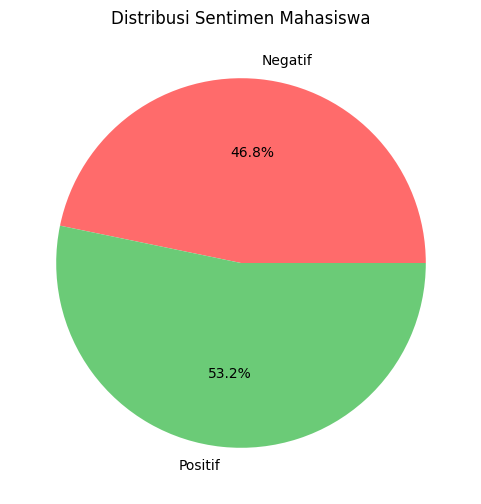

<ipython-input-31-f5e179e81fe8>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='Set2')


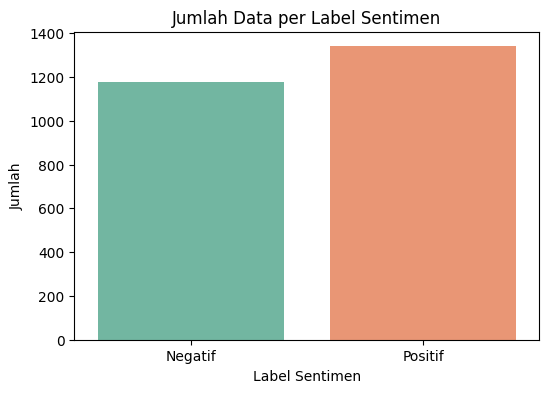

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming timnas_df has a 'Sentiment' column
labels = timnas_df['Sentiment'].map({'Negatif': 0, 'Positif': 1}).tolist()

# Konversi ke DataFrame untuk mudah visualisasi
df = pd.DataFrame({'label': labels})
label_counts = df['label'].value_counts().sort_index()

# Pie Chart
plt.figure(figsize=(6, 6))
# Adjust labels to match the possible sentiment values
plt.pie(label_counts, labels=['Negatif', 'Positif'], autopct='%1.1f%%', colors=['#ff6b6b', '#6bcB77'])
plt.title("Distribusi Sentimen Mahasiswa")
plt.show()

# Bar Chart
plt.figure(figsize=(6, 4))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='Set2')
plt.xticks([0, 1], ['Negatif', 'Positif'])  # Adjust x-axis ticks
plt.title("Jumlah Data per Label Sentimen")
plt.xlabel("Label Sentimen")
plt.ylabel("Jumlah")
plt.show()

# SPLIT DATA & TF-IDF

In [ ]:
corpus = [' '.join(tokens) for tokens in timnas_df['stemming']]

In [ ]:
from sklearn.model_selection import train_test_split

# Langkah 3: Membagi dataset menjadi training dan testing
# Menggunakan kolom 'Sentiment' sebagai target (y)
y = timnas_df['Sentiment']

# Define X using the 'stemming' column, which contains the preprocessed text data
X = timnas_df['stemming'].apply(' '.join)  # Convert list of stemmed words back to text

# Membagi data menjadi training (80%) dan testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 2013
Test set size: 504


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Menggunakan TfidfVectorizer untuk mengubah teks menjadi representasi vektor
tfidf = TfidfVectorizer(max_features=5000)  # max_features bisa diubah sesuai kebutuhan

X_train_tfidf = tfidf.fit_transform(corpus)

X_test_tfidf = tfidf.transform([' '.join(tokens) for tokens in timnas_df.loc[y_test.index, 'stemming']]) # Correct usage

# Cek dimensi data yang sudah ter-vec
print(f"Dimensi X_train_tfidf: {X_train_tfidf.shape}")
print(f"Dimensi X_test_tfidf: {X_test_tfidf.shape}")

Dimensi X_train_tfidf: (2517, 5000)
Dimensi X_test_tfidf: (504, 5000)


# **NAIVE BAYES CLASSIFIER**

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer # import TfidfVectorizer


nb_model = MultinomialNB()

tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

X_test_tfidf = tfidf_vectorizer.transform(X_test)

nb_model.fit(X_train_tfidf, y_train)

y_pred = nb_model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 75.99%

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.83      0.61      0.70       235
     Positif       0.72      0.89      0.80       269

    accuracy                           0.76       504
   macro avg       0.78      0.75      0.75       504
weighted avg       0.77      0.76      0.75       504



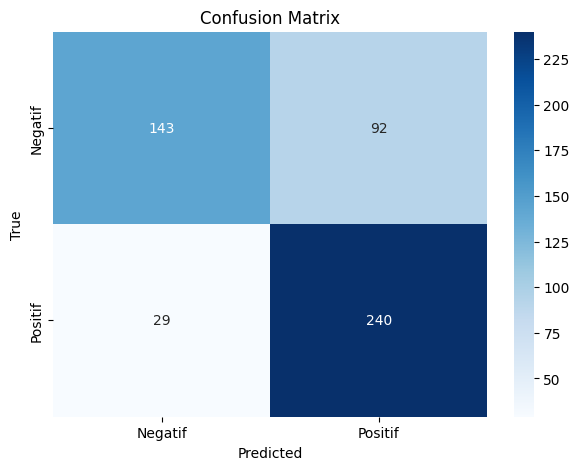

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Membuat confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualisasi confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negatif', 'Positif'], yticklabels=['Negatif', 'Positif'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


<ipython-input-37-f864d401de1c>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=['#2ecc71', '#e74c3c'])


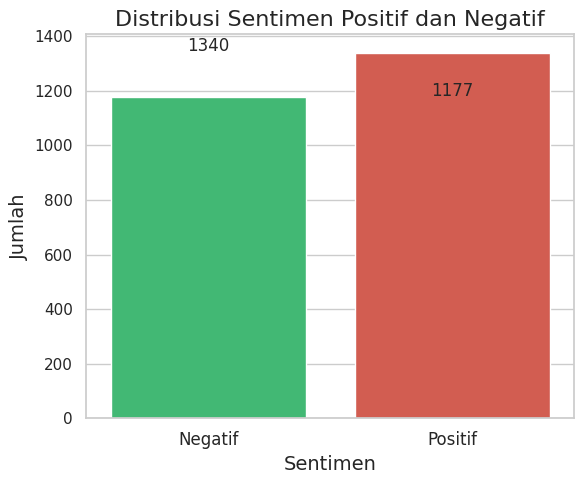

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Hitung jumlah per kategori
sentiment_counts = df['label'].value_counts()

# Set style seaborn
sns.set(style="whitegrid")

# Plot bar chart
plt.figure(figsize=(6, 5))
bar_plot = sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=['#2ecc71', '#e74c3c'])

# Tambahkan label dan judul
plt.title('Distribusi Sentimen Positif dan Negatif', fontsize=16)
plt.xlabel('Sentimen', fontsize=14)
plt.ylabel('Jumlah', fontsize=14)

# Tambahkan nilai di atas bar
for i, value in enumerate(sentiment_counts.values):
    plt.text(i, value + 5, str(value), ha='center', fontsize=12)

# Tambahkan penanda untuk Positif dan Negatif
plt.xticks(ticks=[0, 1], labels=['Negatif', 'Positif'], fontsize=12)

plt.tight_layout()
plt.show()

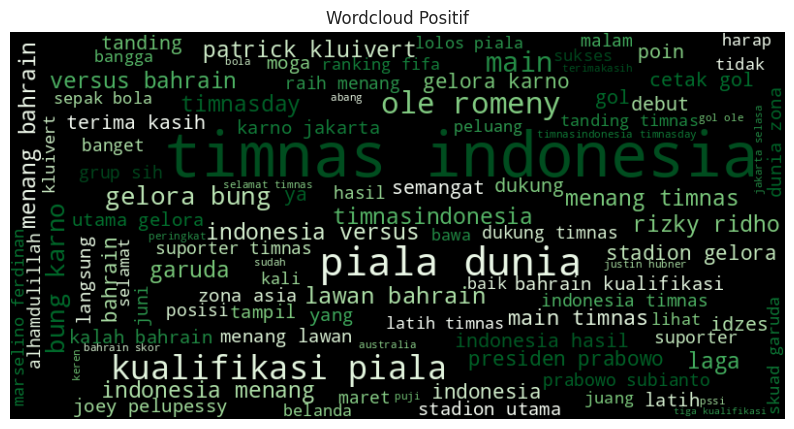

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Mengambil data Positif
positif_text = ' '.join(X_train.loc[y_train == 'Positif'])

# Membuat Wordcloud untuk kata-kata pada label Positif
wordcloud_positif = WordCloud(
    width=800, height=400,
    background_color='black',
    colormap='Greens',
    max_words=100
).generate(positif_text)

plt.figure(figsize=(10, 8))

# Positif
plt.imshow(wordcloud_positif, interpolation='bilinear')
plt.axis('off')
plt.title('Wordcloud Positif')

plt.show()


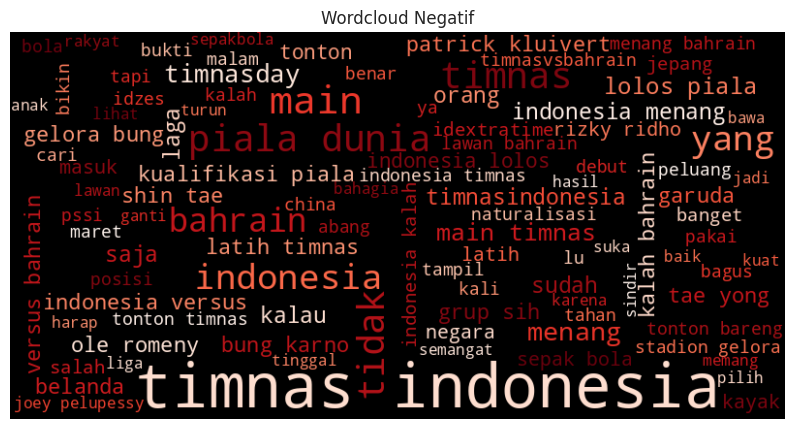

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Mengambil data Negatif
negatif_text = ' '.join(X_train.loc[y_train == 'Negatif'])

# Membuat Wordcloud untuk kata-kata pada label Negatif
wordcloud_negatif = WordCloud(
    width=800, height=400,
    background_color='black',
    colormap='Reds',
    max_words=100
).generate(negatif_text)
if
plt.figure(figsize=(10, 8))

# Negatif
plt.imshow(wordcloud_negatif, interpolation='bilinear')
plt.axis('off')
plt.title('Wordcloud Negatif')

plt.show()